In [0]:
%pip install seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

In [0]:
gold_path = "s3://my-datasets-for-demo/customer-churn-datasets/gold/customer_features"
df_gold = spark.read.format("delta").load(gold_path)
df_gold.printSchema()

root
 |-- CustomerID: integer (nullable = true)
 |-- average_order_value: double (nullable = true)
 |-- total_spend: double (nullable = true)
 |-- purchase_frequency: long (nullable = true)
 |-- recency_days: integer (nullable = true)
 |-- customer_tenure_days: integer (nullable = true)
 |-- return_rate: double (nullable = true)
 |-- churn_label: integer (nullable = true)



In [0]:
# Summary statistics
df_gold.describe().show()

+-------+------------------+-------------------+------------------+------------------+------------------+--------------------+-------------------+------------------+
|summary|        CustomerID|average_order_value|       total_spend|purchase_frequency|      recency_days|customer_tenure_days|        return_rate|       churn_label|
+-------+------------------+-------------------+------------------+------------------+------------------+--------------------+-------------------+------------------+
|  count|              5281|               5281|              5281|              5281|              5281|                5281|               5281|              5281|
|   mean|15324.100170422269|  369.2924165280518|2637.8632864987726| 5.745692103768226|206.81423972732438|  224.50426055671275|0.12111947688448438|0.5659912895284984|
| stddev| 1712.323865306738|  538.2062154372923|12225.544955208541|11.464582024780022| 175.0291116311909|   218.9755616960529|0.17078302540361567|0.4956729500476726|
|   

In [0]:
df = df_gold.toPandas()
type(df)

pandas.core.frame.DataFrame

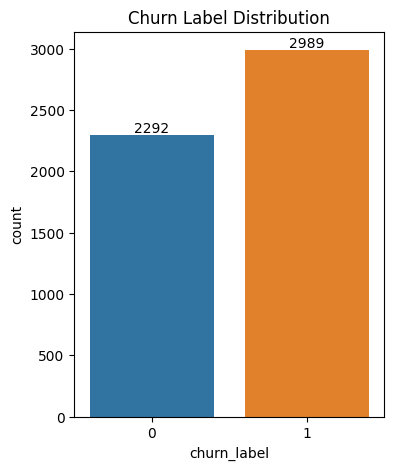

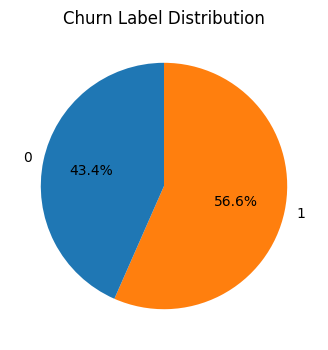

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class balance
color_dict = {
    1: '#ff7f0e',  # Orange for 1
    0: '#1f77b4'   # Blue for 0
}
# Countplot
plt.figure(figsize=(4, 5))
ax = sns.countplot(x='churn_label', 
                   data=df, 
                   hue='churn_label', 
                   legend=False,
                   palette=color_dict)
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.title('Churn Label Distribution')
plt.show()
# Pie chart
plt.figure(figsize=(4, 4))
counts = df['churn_label'].value_counts()
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        counterclock=False, 
        colors=color_dict.values())
plt.title('Churn Label Distribution')
plt.show()



The target classes are relatively balanced, with 43.4% belonging to class 0 and 56.6% to class 1. Therefore, no class-balancing technique is applied at this stage.

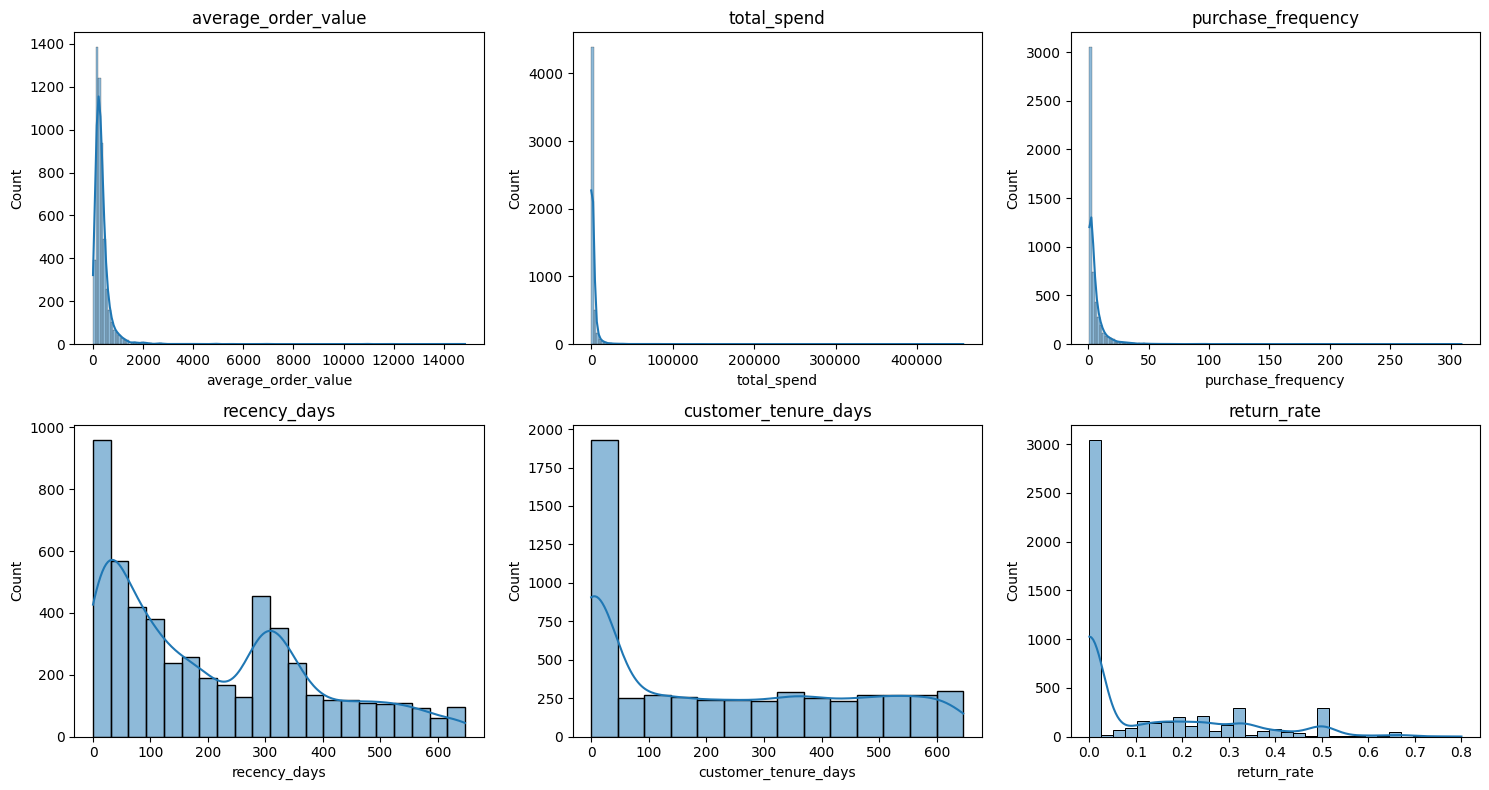

In [0]:
import math

# Feature distributions
feature_cols = [col for col in df.columns if col not in ['churn_label', 'CustomerID']]
ncols = 3
nrows = math.ceil(len(feature_cols) / ncols)

plt.figure(figsize=(15, 4 * nrows))
for i, col in enumerate(feature_cols):
    plt.subplot(nrows, ncols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

In [0]:
numer_data = df.drop('churn_label', axis=1).drop('CustomerID', axis=1)
numer_data.skew()

average_order_value     13.652309
total_spend             23.761168
purchase_frequency      11.070624
recency_days             0.665248
customer_tenure_days     0.456334
return_rate              1.245079
dtype: float64

In [0]:
numer_data.describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
average_order_value,5281.0,369.292417,538.206215,2.9,36.186,88.2,174.668,276.86,409.725000,890.07,1961.887704,14844.766667
total_spend,5281.0,2637.863286,12225.544955,2.9,42.176,111.0,318.240,783.58,2078.540000,8397.41,26279.204000,456780.490000
purchase_frequency,5281.0,5.745692,11.464582,1.0,1.000,1.0,1.000,3.00,6.000000,19.00,43.000000,309.000000
recency_days,5281.0,206.814240,175.029112,0.0,1.000,5.0,49.000,163.00,326.000000,549.00,638.200000,647.000000
customer_tenure_days,5281.0,224.504261,218.975562,0.0,0.000,0.0,0.000,171.00,418.000000,608.00,639.000000,646.000000
return_rate,5281.0,0.121119,0.170783,0.0,0.000,0.0,0.000,0.00,0.230769,0.50,0.605000,0.800000


The percentile analysis shows substantial right tails in `average_order_value`, `total_spend`, and `purchase_frequency`. In particular, their maximum values are considerably higher than the 99th percentiles, indicating the presence of extreme observations. These values will be investigated further to determine whether they represent legitimate high-value customers or potential data-quality issues. No observations are removed solely based on their statistical extremeness.

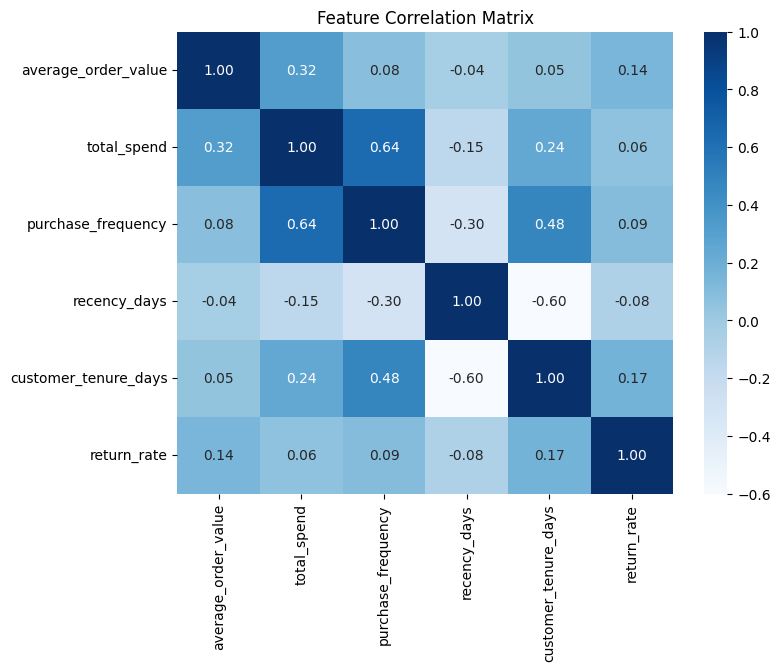

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

# Feature - Feature Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(numer_data.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

There is not any significantly high correlation that indicates near-duplicate features, so all features are retained for modeling.

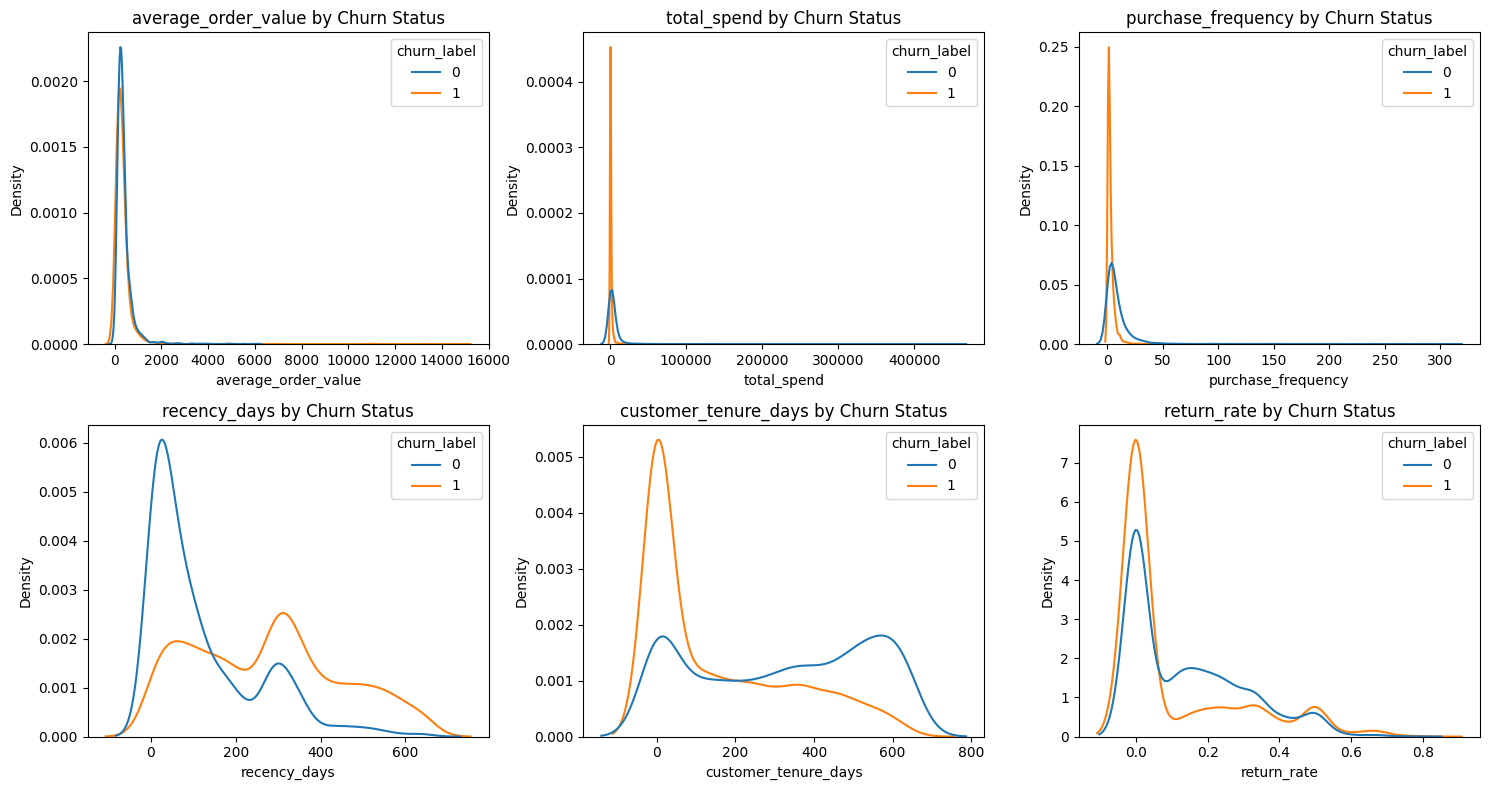

In [0]:
# Compare feature distributions split by Churn
fig = plt.figure(figsize=(15, 4 * nrows))
for i, col in enumerate(numer_data):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.kdeplot(
        data=df,
        x=col,
        hue='churn_label',
        common_norm=False,
        ax=ax
    )
    ax.set_title(f'{col} by Churn Status')
plt.tight_layout()
plt.show()

- **Average Order Value:** The two classes show substantial overlap, with no clear difference in distribution.
- **Total Spend:** Churned customers are more concentrated at lower spending values, while non-churned customers show a broader distribution and greater representation at higher values.
- **Purchase Frequency:** Churned customers are strongly concentrated at low purchase frequencies, while non-churned customers show higher purchase frequencies. This is consistent with its positive correlation with total spend (r = 0.64).
- **Recency:** A clear difference is observed. Churned customers tend to have higher recency, suggesting that longer periods without purchasing are associated with churn.
- **Customer Tenure:** Churned customers are more concentrated at lower tenure values, while non-churned customers have a broader distribution with greater representation at higher tenure.
- **Return Rate:** Both classes are concentrated around low return rates, with substantial overlap. The feature shows less clear separation between classes.